In [ ]:
!pip install -q pandas numpy plotly scikit-learn jinja2 matplotlib seaborn

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm
import matplotlib as mpl



In [ ]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

In [ ]:
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)

In [ ]:
df=pd.read_csv('/content/dataset1_nonghan_water_quality.csv')

In [ ]:
print(f'{df.shape[0]} | {df.shape[1]}')

5000 | 24


In [ ]:
df.describe()

,record_id,date,year_be,month,pH,temp_c,EC_uS_cm,DO_mg_L,BOD_mg_L,COD_mg_L,NH3_mg_L,NO3_mg_L,TP_mg_L,TCB_MPN_100mL,FCB_MPN_100mL,WQI_al_score,is_D,days_to_next_D,target_D_in_30_days
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,1087.000000,5000.000000
mean,2500.500000,2024-12-29 21:24:11.520000256,2567.498400,6.494600,7.165208,28.036000,285.158200,5.874804,3.118362,14.914560,0.635630,1.889027,1.100467,18774.824000,7541.758000,70.678760,0.068000,16.089236,0.180800
min,1.000000,2024-01-01 00:00:00,2567.000000,1.000000,5.910000,22.000000,92.000000,0.720000,0.300000,4.000000,0.010000,0.600000,0.150000,420.000000,99.000000,27.100000,0.000000,1.000000,0.000000
25%,1250.750000,2024-07-02 00:00:00,2567.000000,3.000000,6.920000,26.100000,229.000000,4.650000,1.150000,5.000000,0.143000,0.870000,0.318000,3419.250000,1284.750000,59.775000,0.000000,3.000000,0.000000
50%,2500.500000,2024-12-30 12:00:00,2567.000000,6.000000,7.170000,28.000000,276.000000,6.210000,2.560000,12.400000,0.455000,1.900000,1.060500,7613.000000,2966.500000,76.600000,0.000000,8.000000,0.000000
75%,3750.250000,2025-06-29 00:00:00,2568.000000,9.250000,7.400000,30.000000,341.000000,7.180000,4.800000,21.900000,1.064000,2.762250,1.685500,21254.750000,8217.250000,85.600000,0.000000,21.000000,0.000000
max,5000.000000,2025-12-30 00:00:00,2568.000000,12.000000,8.440000,34.700000,504.000000,9.500000,9.550000,50.600000,2.526000,6.000000,4.000000,360584.000000,179815.000000,97.900000,1.000000,127.000000,1.000000
std,1443.520003,NaN,0.500047,3.435918,0.356559,2.454654,72.903507,1.715508,2.314304,10.473281,0.578575,1.073993,0.838408,28736.205068,12224.395612,17.699767,0.251771,19.762409,0.384891


In [ ]:
display(df.head())

,record_id,date,year_be,month,season,station_id,station_type,tambon,pH,temp_c,...,NH3_mg_L,NO3_mg_L,TP_mg_L,TCB_MPN_100mL,FCB_MPN_100mL,WQI_al_score,WQI_al_class,is_D,days_to_next_D,target_D_in_30_days
1596,1597,2024-01-04,2567,1,ฤดูแล้ง,BNH01,ลำห้วย (Tributary),ธาตุนาเวง,7.30,23.4,...,1.643,3.192,2.187,64255,22604,44.0,C (พอใช้),0,2.0,1
3574,3575,2024-01-05,2567,1,ฤดูแล้ง,BNH01,ลำห้วย (Tributary),ธาตุนาเวง,6.63,25.3,...,1.559,3.601,2.269,121866,70573,43.7,C (พอใช้),0,1.0,1
1063,1064,2024-01-06,2567,1,ฤดูแล้ง,BNH01,ลำห้วย (Tributary),ธาตุนาเวง,6.71,25.7,...,2.526,3.905,2.687,10946,5611,39.2,D (เสื่อมโทรม),1,5.0,1
1925,1926,2024-01-11,2567,1,ฤดูแล้ง,BNH01,ลำห้วย (Tributary),ธาตุนาเวง,7.54,24.8,...,1.517,3.335,2.263,9924,2167,38.5,D (เสื่อมโทรม),1,9.0,1
2553,2554,2024-01-13,2567,1,ฤดูแล้ง,BNH01,ลำห้วย (Tributary),ธาตุนาเวง,7.17,23.7,...,1.647,3.195,2.296,8990,2292,40.6,C (พอใช้),0,7.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1596 to 1730
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            5000 non-null   int64         
 1   date                 5000 non-null   datetime64[ns]
 2   year_be              5000 non-null   int64         
 3   month                5000 non-null   int64         
 4   season               5000 non-null   object        
 5   station_id           5000 non-null   object        
 6   station_type         5000 non-null   object        
 7   tambon               5000 non-null   object        
 8   pH                   5000 non-null   float64       
 9   temp_c               5000 non-null   float64       
 10  EC_uS_cm             5000 non-null   float64       
 11  DO_mg_L              5000 non-null   float64       
 12  BOD_mg_L             5000 non-null   float64       
 13  COD_mg_L             5000 non-null 

In [ ]:
df.isna().sum()

,0
record_id,0
date,0
year_be,0
month,0
season,0
station_id,0
station_type,0
tambon,0
pH,0
temp_c,0


ตำบลที่ดีที่สุด 10 อันดับ

In [ ]:
df.groupby("tambon")["WQI_al_score"]\
.mean()\
.sort_values(ascending=False).head(10)

In [ ]:
def summarize_df(df, name):
    print(f"=== Summary Schema: {name} ===")
    summary = pd.DataFrame({
        'DataType': df.dtypes,
        'NullCount': df.isnull().sum(),
        'NullRatio(%)': (df.isnull().sum() / len(df) * 100).round(2),
        'N_Unique': df.nunique()
    })
    print(summary)
    print("-" * 50)
print(summarize_df(df, "df") )

## 📊 อธิบายคอลัมน์ (Data Dictionary)

ข้อมูลชุดนี้มี **5,000 แถว** และ **21 คอลัมน์** สามารถแบ่งออกเป็น 4 กลุ่มหลัก เพื่อให้ง่ายต่อการทำความเข้าใจ ดังนี้:

| กลุ่มข้อมูล | คอลัมน์ (ตัวแปร) | คำอธิบาย |
| :--- | :--- | :--- |
| **1. ข้อมูลบริบท** <br>*(Context)* | `record_id`, `date`, `year_be`, `month`, `season` | ข้อมูลเวลาและฤดูกาล |
| | `station_id`, `station_type` | ประเภทสถานี (แบ่งเป็น 'ลำห้วย' และ 'หนองหาร') |
| | `tambon` | ตำบลที่ตั้งสถานี (เช่น เชียงเครือ, ท่าแร่, ธาตุนาเวง ฯลฯ) |
| **2. คุณสมบัติทางกายภาพ** | `pH`, `temp_c`, `EC_uS_cm` | ความเป็นกรด-ด่าง, อุณหภูมิ, และค่าความนำไฟฟ้า (บ่งบอกแร่ธาตุหรือความเค็ม) |
| **3. มลพิษและชีวเคมี** <br>*(The Villains)* | `DO_mg_L` | ปริมาณออกซิเจนละลายน้ำ (**ยิ่งเยอะยิ่งดี**) |
| | `BOD_mg_L`, `COD_mg_L` | ค่าความต้องการออกซิเจนฯ (ชี้วัดความเน่าเสีย **ยิ่งเยอะยิ่งแย่**) |
| | `NH3_mg_L`, `NO3_mg_L`, `TP_mg_L` | แอมโมเนีย, ไนเตรต, ฟอสฟอรัส (ตัวแทนปุ๋ยเกษตร/น้ำทิ้งชุมชน) |
| | `TCB_MPN_100mL`, `FCB_MPN_100mL` | ปริมาณแบคทีเรียโคลิฟอร์ม (ตัวชี้วัดการปนเปื้อนของสิ่งปฏิกูล) |
| **4. ตัวแปรเป้าหมาย** <br>*(Target Variables)*| `WQI_al_score` | คะแนนคุณภาพน้ำ |
| | `WQI_al_class` | เกณฑ์คุณภาพน้ำ (A=ดีมาก, B=ดี, C=พอใช้, D=เสื่อมโทรม) |

---

# **ภาพรวมของคุณภาพน้ำ: แหล่งน้ำนี้ส่วนใหญ่มีคุณภาพอยู่ในเกณฑ์ใด? มีสัดส่วนของน้ำที่ "เสื่อมโทรม" มากน้อยแค่ไหนและ "station" แต่ละพื้นที่เป็นอย่างไร**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --- ตั้งค่าข้อมูลสำหรับการพล็อตกราฟ ---
wqi_counts = df['WQI_al_class'].value_counts()
# เพื่อให้กราฟเรียงลำดับอย่างถูกต้องและสีตรงกัน กำหนดลำดับไว้ก่อน
wqi_order = ['A (ดีมาก)', 'B (ดี)', 'C (พอใช้)', 'D (เสื่อมโทรม)']
wqi_counts = wqi_counts.reindex(wqi_order).dropna()

# ตั้งค่าสี (เขียว, ฟ้า/น้ำเงิน, เหลือง, แดง)
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e74c3c']

# --- สร้าง Subplots พื้นที่ 1 แถว 2 คอลัมน์ ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].pie(wqi_counts,
            labels=wqi_counts.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('สัดส่วนคุณภาพน้ำโดยรวมของหนองหาร', fontsize=16)

sns.countplot(data=df,
              x='station_type',
              hue='WQI_al_class',
              order=['หนองหาร (Lake)', 'ลำห้วย (Tributary)'],
              hue_order=wqi_order,
              palette=colors,
              ax=axes[1]) # ระบุให้พล็อตลงในแกนที่ 2
axes[1].set_title('เปรียบเทียบคุณภาพน้ำระหว่าง หนองหาร และ ลำห้วย', fontsize=16)
axes[1].set_xlabel('แหล่งน้ำ (Station Type)', fontsize=12)
axes[1].set_ylabel('จำนวนครั้งที่ตรวจวัดพบ (Records)', fontsize=12)

# จัดตำแหน่ง Legend ให้อยู่ข้างนอกกราฟเพื่อไม่ให้บังแท่งข้อมูล
axes[1].legend(title='ระดับคุณภาพน้ำ (WQI Class)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

จากข้อมูลทำให้ทราบว่าภาพร่วมของ WQI ส่วนมากไม่ได้แย่เพียง 6.8% จากทั้งหมดและ station หนองหารไม่มีระดับคุณภาาพน้ำระดับ D (เสื่อมโทรม)

In [ ]:
df.groupby("station_type")["WQI_al_score"]\
.mean()\
.sort_values(ascending=False)

# **10 อันดับตำบลที่มีค่า WQI มากที่สุด และ 10อันดับตำบลที่มีค่า WQI มากที่สุด**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
df = pd.read_csv('dataset1_nonghan_water_quality.csv')

# หาค่าเฉลี่ยคุณภาพน้ำ (WQI) ของแต่ละตำบล
tambon_wqi = df.groupby('tambon')['WQI_al_score'].mean().reset_index()

# 10 ตำบลคุณภาพน้ำดีที่สุด
top_10_best = tambon_wqi.sort_values(by='WQI_al_score', ascending=False).head(10)
print("--- 🌟 10 ตำบลคุณภาพน้ำดีที่สุด (WQI เฉลี่ยสูงสุด) ---")
print(top_10_best.to_string(index=False))
print("\n" + "="*50 + "\n")

# 10 ตำบลคุณภาพน้ำแย่ที่สุด
top_10_worst = tambon_wqi.sort_values(by='WQI_al_score', ascending=True).head(10)
print("--- ⚠️ 10 ตำบลคุณภาพน้ำแย่ที่สุด (WQI เฉลี่ยต่ำสุด) ---")
print(top_10_worst.to_string(index=False))

# **พื้นที่ตำบลใดบ้างที่เป็นจุดวิกฤต (Hotspot) ของน้ำเสื่อมโทรม เพื่อให้สามารถลงพื้นที่จัดการได้ตรงจุด?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_d = df[df['WQI_al_class'] == 'D (เสื่อมโทรม)']

tambon_counts = df_d['tambon'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(tambon_counts.index, tambon_counts.values, color='#e74c3c', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

plt.title('อันดับตำบลที่พบคุณภาพน้ำ "เสื่อมโทรม" (ระดับ D) มากที่สุด', fontsize=16, fontweight='bold')
plt.ylabel('จำนวนครั้งที่ตรวจพบ', fontsize=12)
plt.xlabel('ตำบล', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

ผู้นำชุมชนและ อบต. (ในพื้นที่ ธาตุนาเวง, เมืองสกล, ท่าแร่, นาแก้ว): ได้รับ "เป้าหมายที่ชัดเจน" ไม่ต้องหว่านแหแก้ปัญหาทั้งจังหวัด สามารถนำงบประมาณหรือเจ้าหน้าที่ลงไปตรวจสอบแหล่งปล่อยน้ำทิ้งทางการเกษตร หรือฟาร์มปศุสัตว์ใน 4 ตำบลนี้ได้ทันที

หน่วยงานเกษตรอำเภอ/จังหวัด: สามารถใช้ข้อมูลนี้เพื่อเข้าไปให้ความรู้ชาวบ้านเฉพาะกลุ่ม ในเรื่องการลดใช้ปุ๋ยเคมี (ซึ่งเป็นสาเหตุของไนเตรต/ฟอสฟอรัส) หรือการจัดการน้ำเสียจากฟาร์มก่อนปล่อยลงแหล่งน้ำ

ชาวบ้านทั่วไป: ทำให้รู้ว่าพื้นที่ตนเองมีความเสี่ยง ควรหลีกเลี่ยงการนำน้ำไปใช้อุปโภคบริโภคโดยตรง หรือใช้น้ำอย่างระมัดระวังมากขึ้น

#ข้อมูลความสัมพันธ์กันของสารเคมีต่างๆ

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. โหลดข้อมูล
df = pd.read_csv("dataset1_nonghan_water_quality.csv")

# 2. เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 3. หาค่า Correlation เทียบกับ WQI_al_score
corr_with_wqi = numeric_df.corr()['WQI_al_score'].drop('WQI_al_score')

# 4. คัดกรองเอาเฉพาะสารที่มีความสัมพันธ์สูง (ค่าสัมบูรณ์ > 0.6)
# วิธีนี้จะตัดพวก record_id, year, month, temp, pH ที่ไม่ค่อยมีผลออกไปโดยอัตโนมัติ
highly_correlated_cols = corr_with_wqi[corr_with_wqi.abs() > 0.6].index.tolist()

# 5. เติม WQI_al_score กลับเข้าไปในลิสต์เพื่อเอาไปสร้างกราฟ
cols_to_plot = highly_correlated_cols + ['WQI_al_score']

# 6. สร้าง Correlation Matrix เฉพาะสารที่คัดมาแล้ว
filtered_corr = numeric_df[cols_to_plot].corr()

# 7. พล็อต Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, cmap='RdYlGn', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap: Highly Correlated Substances vs WQI', fontsize=14)
plt.tight_layout()
plt.show()

ปัจจัยบวก: พระเอกของแหล่งน้ำ (ยิ่งเยอะ ยิ่งดี)

DO (ออกซิเจนละลายน้ำ) | r = 0.96 : หากมีค่าสูงบ่งบอกว่าน้ำสะอาด มีการไหลเวียนที่ดี ระบบนิเวศสมดุล และสัตว์น้ำสามารถดำรงชีวิตได้ตามปกติ

🔴 กลุ่มวิกฤต: ตัวการหลักที่ทำให้น้ำเสื่อมโทรมอย่างรุนแรง (r < -0.90)

NH3 (แอมโมเนีย) | r = -0.95 : เป็นพิษสูงต่อสัตว์น้ำ แม้ปริมาณน้อยก็ทำให้ปลาตายได้ บ่งชี้ถึงการลักลอบปล่อยน้ำทิ้งจากฟาร์มปศุสัตว์หรือชุมชนที่ยังไม่ได้บำบัด

TP (ฟอสฟอรัสรวม) | r = -0.94 : ตัวการสำคัญที่ทำให้เกิด "สาหร่ายบูม" (น้ำเขียวข้นและเน่าเสีย) มักมาจากการชะล้างปุ๋ยเคมีหรือน้ำทิ้งที่มีผงซักฟอก

NO3 (ไนเตรต) | r = -0.92 : ทำงานร่วมกับฟอสฟอรัสในการเร่งวัชพืชน้ำ (เช่น ผักตบชวา) มักมาจากปุ๋ยตกค้างทางการเกษตร

BOD (ความต้องการออกซิเจนทางชีวเคมี) | r = -0.91 : ชี้วัดปริมาณ "ขยะอินทรีย์" หากมีค่าสูง แบคทีเรียจะดึงออกซิเจนในน้ำไปใช้ย่อยสลายของเสียจนหมด ทำให้สัตว์น้ำขาดอากาศหายใจ

🟠 กลุ่มสารตกค้าง: มลพิษสะสม (r = -0.80)

EC (ค่าความนำไฟฟ้า) | r = -0.80 : ชี้วัดปริมาณเกลือแร่หรือโลหะที่ละลายในน้ำ หากสูงเกินไปน้ำจะกระด้างหรือมีความเค็ม ไม่เหมาะกับการนำไปรดพืชผล

COD (ความต้องการออกซิเจนทางเคมี) | r = -0.80 : คล้าย BOD แต่ครอบคลุมสารเคมีที่ย่อยสลายยาก มักเชื่อมโยงกับน้ำเสียอุตสาหกรรมหรือสารเคมีรุนแรง

🟡 กลุ่มเชื้อโรค: ภัยเงียบต่อสุขภาพ (r = -0.61 ถึง -0.64)

TCB & FCB (แบคทีเรียโคลิฟอร์ม) | r = -0.64, -0.61 : เป็นตัวแทนของ "สิ่งปฏิกูลและอุจจาระ" บ่งชี้ว่าแหล่งน้ำมีการปนเปื้อนของเชื้อโรค หากสัมผัสหรือนำไปบริโภคจะเสี่ยงต่อโรคทางเดินอาหารและท้องร่วง

💡 สรุปเพื่อการจัดการ (Actionable Insight):
ในการฟื้นฟูคุณภาพน้ำที่เสื่อมโทรม (ระดับ D) หน่วยงานควรพุ่งเป้าไปที่การจัดการและควบคุมแหล่งกำเนิด แอมโมเนีย (NH3), ฟอสฟอรัส (TP) และ ไนเตรต (NO3) เป็นอันดับแรก เนื่องจากการลดสารตั้งต้นเหล่านี้จะช่วยเพิ่มออกซิเจนในน้ำ (DO) และดึงคะแนน WQI ภาพรวมให้กลับมาอยู่ในเกณฑ์มาตรฐานได้อย่างตรงจุดที่สุด

#**สารจากจุดวิกฤ**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2. กำหนดสารมลพิษที่จะวิเคราะห์ (ตัวชี้วัดการเกษตรและน้ำเสีย)
pollutants = ['BOD_mg_L', 'NO3_mg_L', 'TP_mg_L', 'NH3_mg_L']
pollutant_labels = ['BOD\n(สารอินทรีย์)', 'NO3\n(ไนเตรต/ปุ๋ย)', 'TP\n(ฟอสฟอรัส)', 'NH3\n(แอมโมเนีย)']

# 3. กรองเฉพาะน้ำเสื่อมโทรม ใน 4 ตำบลวิกฤต
df_d = df[df['WQI_al_class'] == 'D (เสื่อมโทรม)']
critical_tambons = ['ธาตุนาเวง', 'เมืองสกลนคร', 'ท่าแร่', 'นาแก้ว']
df_critical = df_d[df_d['tambon'].isin(critical_tambons)]

# 4. คำนวณค่าเฉลี่ยของสารมลพิษในพื้นที่วิกฤต vs น้ำปกติ (Class A)
mean_critical = df_critical[pollutants].mean().values
mean_baseline = df[df['WQI_al_class'] == 'A (ดีมาก)'][pollutants].mean().values

# 5. สร้างกราฟแท่งคู่เปรียบเทียบ
x = np.arange(len(pollutants))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, mean_baseline, width, label='น้ำสะอาดปกติ (Class A)', color='#2ecc71', edgecolor='black')
rects2 = ax.bar(x + width/2, mean_critical, width, label='น้ำเสื่อมโทรม (4 ตำบลวิกฤต)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('ความเข้มข้นเฉลี่ย (mg/L)', fontsize=12)
ax.set_title('เปรียบเทียบปริมาณสารมลพิษ: 4 ตำบลวิกฤต vs น้ำสะอาด', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pollutant_labels, fontsize=12)
ax.legend(fontsize=12)

# ฟังก์ชันใส่ตัวเลขบนกราฟ
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

จากกราฟเราจะเห็นชัดเจนเลยว่า ทำไมคุณภาพน้ำถึงตกไปอยู่ระดับ D:

BOD (ความสกปรกของน้ำในรูปสารอินทรีย์) กระโดดสูงถึง 6.96 mg/L (จากปกติแค่ 1.26)

NO3 (ไนเตรต - มาจากปุ๋ยเคมี) พุ่งจาก 0.96 เป็น 3.62 mg/L (เพิ่มขึ้นเกือบ 4 เท่า)

TP (ฟอสฟอรัสรวม - มาจากปุ๋ยเคมีและผงซักฟอก) พุ่งจาก 0.39 เป็น 2.50 mg/L (เพิ่มขึ้นกว่า 6 เท่า!)

NH3 (แอมโมเนีย - มาจากของเสีย ปศุสัตว์) สูงขึ้นเกือบ 10 เท่า!

สรุปทางวิชาการ: การที่ ไนเตรต (NO3) และ ฟอสฟอรัส (TP) พุ่งทะยานสูงผิดปกติขนาดนี้ เป็นการชี้เป้าที่ชัดเจน 100% ว่ามลพิษหลักมาจาก "กิจกรรมการเกษตร" (เช่น การชะล้างปุ๋ยจากแปลงนาหรือสวน ลงสู่ลำห้วยใน 4 ตำบลนี้)

# **ฤดูไหนและช่วงไหนที่เกิดปัญหามากที่สุด**

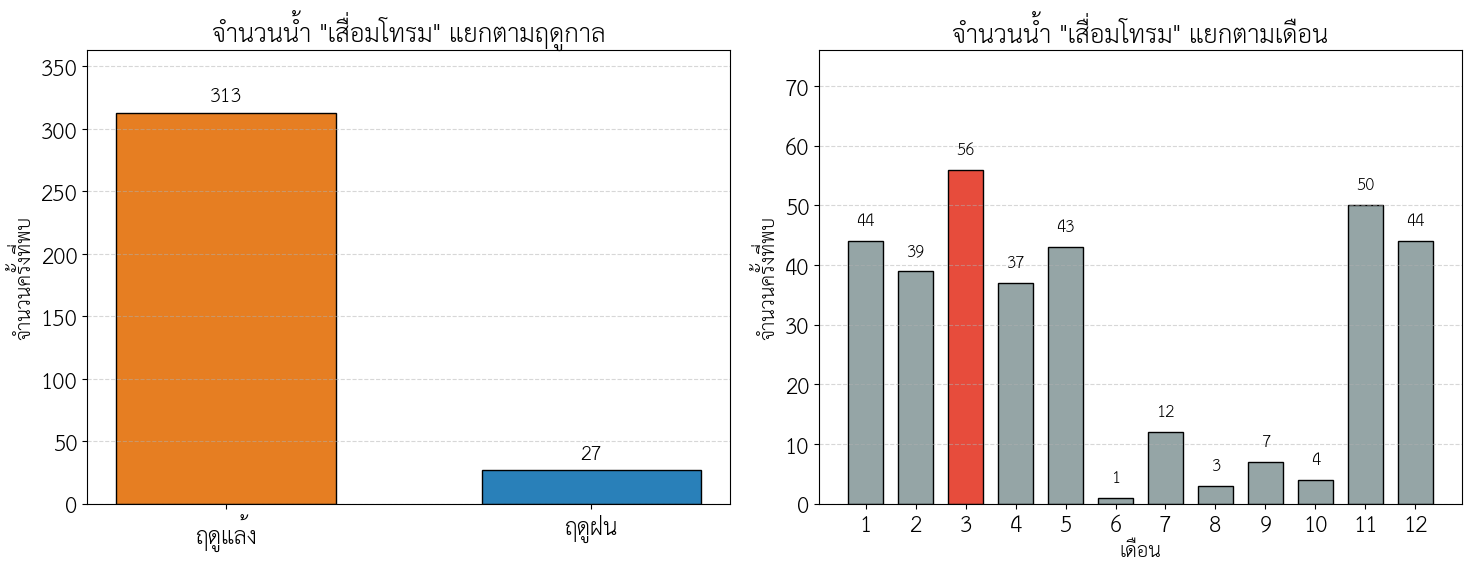

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 1. ตั้งค่าฟอนต์ภาษาไทย
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)

# 2. โหลดข้อมูลและกรองเฉพาะกลุ่มเสื่อมโทรม
df = pd.read_csv('dataset1_nonghan_water_quality.csv')
df_d = df[df['WQI_al_class'] == 'D (เสื่อมโทรม)']

# เตรียมข้อมูลสำหรับกราฟทั้ง 2 รูป
season_counts = df_d['season'].value_counts()
month_counts = df_d['month'].value_counts().sort_index() # เรียงตามลำดับเดือน 1-12

# 3. สร้างพื้นที่กราฟแบบ 1 แถว 2 คอลัมน์
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- กราฟที่ 1: เปรียบเทียบตามฤดูกาล ---
bars1 = axes[0].bar(season_counts.index, season_counts.values,
                    color=['#e67e22', '#2980b9'], edgecolor='black', width=0.6)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval),
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

axes[0].set_title('จำนวนน้ำ "เสื่อมโทรม" แยกตามฤดูกาล', fontsize=18)
axes[0].set_ylabel('จำนวนครั้งที่พบ', fontsize=14)
axes[0].set_ylim(0, max(season_counts.values) + 50)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- กราฟที่ 2: เปรียบเทียบตามเดือน ---
# กำหนดให้เดือนที่เจอน้ำเสื่อมโทรมเยอะที่สุดเป็นสีแดง นอกนั้นสีเทา
max_month_val = month_counts.max()
colors = ['#e74c3c' if val == max_month_val else '#95a5a6' for val in month_counts.values]

bars2 = axes[1].bar(month_counts.index.astype(str), month_counts.values,
                    color=colors, edgecolor='black', width=0.7)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_title('จำนวนน้ำ "เสื่อมโทรม" แยกตามเดือน', fontsize=18)
axes[1].set_xlabel('เดือน', fontsize=14)
axes[1].set_ylabel('จำนวนครั้งที่พบ', fontsize=14)
axes[1].set_ylim(0, max_month_val + 20)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# ปรับระยะห่างและแสดงผล
plt.tight_layout()
plt.show()

ช่วงฤดูฝน (พบแค่ 27 ครั้ง): ปริมาณน้ำฝนที่ตกลงมามหาศาลจะช่วยชะล้างและ "เจือจาง" ความเข้มข้นของปุ๋ย (ไนเตรต/ฟอสฟอรัส) และของเสียจากการเกษตร ทำให้น้ำโดยรวมยังอยู่ในเกณฑ์ดี

ช่วงฤดูแล้ง (พบถึง 313 ครั้ง): ปริมาณน้ำในหนองหารและลำห้วยลดต่ำลงอย่างมาก เมื่อน้ำมีน้อย แต่ปริมาณของเสียที่ไหลลงแหล่งน้ำยังเท่าเดิม (หรืออาจมีการสูบน้ำไปใช้เกษตรกรรมมากทำให้เหลือคลองแห้ง) ของเสียจึง "เข้มข้น" ขึ้น ทำให้ค่า DO (ออกซิเจน) ต่ำลง และน้ำเน่าเสียเร็วขึ้น


ชาวบ้านและกลุ่มผู้ใช้น้ำประปาหมู่บ้าน:

ทำให้รู้ว่าต้อง "ระวังการใช้น้ำในช่วงฤดูแล้งเป็นพิเศษ" หากจำเป็นต้องใช้น้ำจากแหล่งน้ำธรรมชาติ ควรมีการพักน้ำหรือต้มฆ่าเชื้อ เพราะความเข้มข้นของมลพิษจะสูงกว่าปกติ

หน่วยงานชลประทาน และ อบต.:

การบริหารจัดการน้ำ (Water Management): สามารถใช้เป็นหลักฐานในการวางแผนปล่อยน้ำดีจากเขื่อน/อ่างเก็บน้ำ มาช่วย "ผลักดันและเจือจาง" น้ำเสียในช่วงฤดูแล้ง (1 - 5 และ 11-12)

การจัดสรรงบประมาณ: ไม่ต้องเสียงบประมาณลงพื้นที่สุ่มตรวจถี่ๆ ในหน้าฝน แต่ให้ทุ่มกำลังและงบประมาณในการเฝ้าระวัง/บำบัดน้ำ ในช่วงฤดูแล้งแทน

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 1. ดาวน์โหลดและตั้งค่าฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)

# 2. โหลดข้อมูล
df = pd.read_csv('dataset1_nonghan_water_quality.csv')

# 3. สร้าง Mapping เพื่อเปลี่ยนชื่อกลุ่มและจัดหมวดหมู่
class_mapping = {
    'A (ดีมาก)': '1. น้ำสะอาด (Clean)',
    'B (ดี)': '2. น้ำปานกลาง (Moderate)',
    'C (พอใช้)': '3. น้ำเสี่ยง (At Risk)',
    'D (เสื่อมโทรม)': '4. น้ำวิกฤติ (Critical)'
}
df['Water_Profile'] = df['WQI_al_class'].map(class_mapping)

# 4. เลือกตัวแปรที่บ่งบอกลักษณะของน้ำ และหาค่าเฉลี่ย
key_cols = ['DO_mg_L', 'BOD_mg_L', 'NH3_mg_L', 'TCB_MPN_100mL']
profile_summary = df.groupby('Water_Profile')[key_cols].mean().round(2)

# 5. สร้างกราฟ Subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b'] # สี: เขียว, เหลือง, ส้ม, แดง

# กราฟที่ 1: ออกซิเจน (DO)
axes[0, 0].bar(profile_summary.index, profile_summary['DO_mg_L'], color=colors, edgecolor='black')
axes[0, 0].set_title('ออกซิเจนละลายน้ำ (DO) - ยิ่งสูงยิ่งดี', fontsize=18)
axes[0, 0].set_ylabel('mg/L')

# กราฟที่ 2: ความสกปรก (BOD)
axes[0, 1].bar(profile_summary.index, profile_summary['BOD_mg_L'], color=colors, edgecolor='black')
axes[0, 1].set_title('ความสกปรก (BOD) - ยิ่งต่ำยิ่งดี', fontsize=18)
axes[0, 1].set_ylabel('mg/L')

# กราฟที่ 3: แอมโมเนีย (NH3)
axes[1, 0].bar(profile_summary.index, profile_summary['NH3_mg_L'], color=colors, edgecolor='black')
axes[1, 0].set_title('แอมโมเนีย (NH3) - ยิ่งต่ำยิ่งดี', fontsize=18)
axes[1, 0].set_ylabel('mg/L')

# กราฟที่ 4: แบคทีเรีย (TCB)
axes[1, 1].bar(profile_summary.index, profile_summary['TCB_MPN_100mL'], color=colors, edgecolor='black')
axes[1, 1].set_title('แบคทีเรีย (TCB) - ยิ่งต่ำยิ่งดี', fontsize=18)
axes[1, 1].set_ylabel('MPN/100mL')

# จัดรูปแบบแกน X ให้สวยงาม
for ax in axes.flatten():
    ax.tick_params(axis='x', labelrotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# ใส่ชื่อเรื่องหลักของกราฟ
plt.suptitle('Water Quality Profiles (ลักษณะเฉพาะของคุณภาพน้ำแต่ละกลุ่ม)', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()

# ***`แนวโน้ม เทรนของแต่ละปี`***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 3. หาค่าเฉลี่ยของ WQI, BOD และ DO แยกตามปี (year_be)
yearly_trend = df.groupby('year_be')[['WQI_al_score', 'BOD_mg_L', 'DO_mg_L']].mean().round(2)

# 4. สร้างพื้นที่กราฟ 1 แถว 3 คอลัมน์
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
years = yearly_trend.index.astype(str)

# --- กราฟที่ 1: เปรียบเทียบแนวโน้ม WQI (ยิ่งสูงยิ่งดี) ---
bars1 = axes[0].bar(years, yearly_trend['WQI_al_score'], color=['#3498db', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('แนวโน้มคุณภาพน้ำ (WQI)', fontsize=18, fontweight='bold')
axes[0].set_ylabel('คะแนน WQI', fontsize=14)
axes[0].set_ylim(0, 100) # WQI คะแนนเต็ม 100
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height()}",
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

# --- กราฟที่ 2: เปรียบเทียบแนวโน้ม BOD (ยิ่งต่ำยิ่งดี) ---
bars2 = axes[1].bar(years, yearly_trend['BOD_mg_L'], color=['#e67e22', '#d35400'], edgecolor='black', width=0.5)
axes[1].set_title('แนวโน้มความสกปรก (BOD)', fontsize=18, fontweight='bold')
axes[1].set_ylabel('BOD (mg/L)', fontsize=14)
axes[1].set_ylim(0, yearly_trend['BOD_mg_L'].max() + 1.5)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height()}",
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

# --- กราฟที่ 3: เปรียบเทียบแนวโน้ม DO (ยิ่งสูงยิ่งดี) ---
bars3 = axes[2].bar(years, yearly_trend['DO_mg_L'], color=['#9b59b6', '#8e44ad'], edgecolor='black', width=0.5)
axes[2].set_title('แนวโน้มออกซิเจนละลายน้ำ (DO)', fontsize=18, fontweight='bold')
axes[2].set_ylabel('DO (mg/L)', fontsize=14)
axes[2].set_ylim(0, yearly_trend['DO_mg_L'].max() + 2)
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height()}",
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

# ปรับรูปแบบตารางพื้นหลัง
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel('ปี พ.ศ.', fontsize=14)

# แสดงผลกราฟ
plt.suptitle('Time Trend: เปรียบเทียบการเปลี่ยนแปลงของคุณภาพน้ำระหว่างปี 2567 - 2568', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.85) # เผื่อพื้นที่ให้ชื่อเรื่องหลัก
plt.show()

แนวโน้มของคุณภาพแย่ลง แต่สารต่างๆที่ทำให้คุณภาพน้ำแย่กลับมากขึ้น

ข้อเสนอแนะและแนวทางแก้ปัญหา

modeling

Starting Grid Search...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters: {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9430

Test Set Accuracy: 0.9350
Classification Report:
                 precision    recall  f1-score   support

     A (ดีมาก)       0.94      1.00      0.97       451
        B (ดี)       0.95      0.91      0.93       296
     C (พอใช้)       0.92      0.89      0.90       185
D (เสื่อมโทรม)       0.87      0.78      0.82        68

      accuracy                           0.94      1000
     macro avg       0.92      0.89      0.90      1000
  weighted avg       0.93      0.94      0.93      1000

Confusion Matrix:
 [[450   1   0   0]
 [ 28 268   0   0]
 [  0  13 164   8]
 [  0   0  15  53]]


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.dr

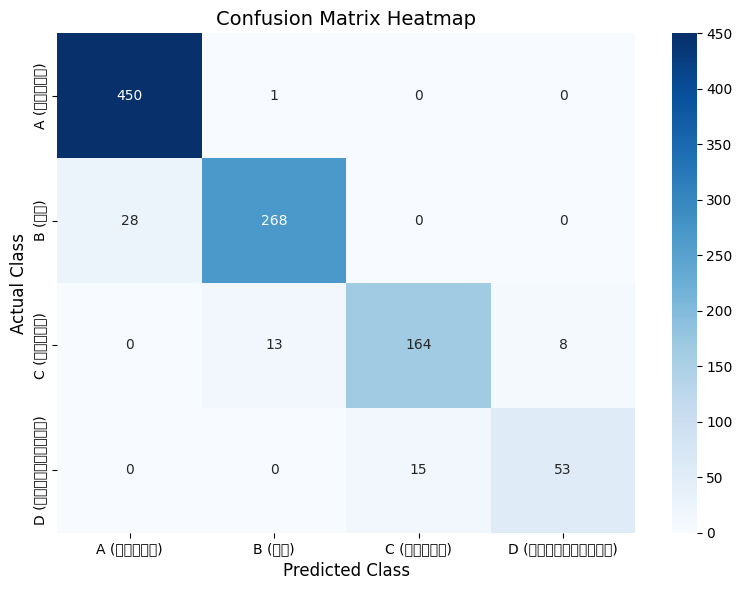

/tmp/ipykernel_550/1790719797.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[top_indices], y=X.columns[top_indices], palette='viridis')
/tmp/ipykernel_550/1790719797.py:85: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1790719797.py:85: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1790719797.py:85: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1790719797.py:85: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1790719797.py:85: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu 

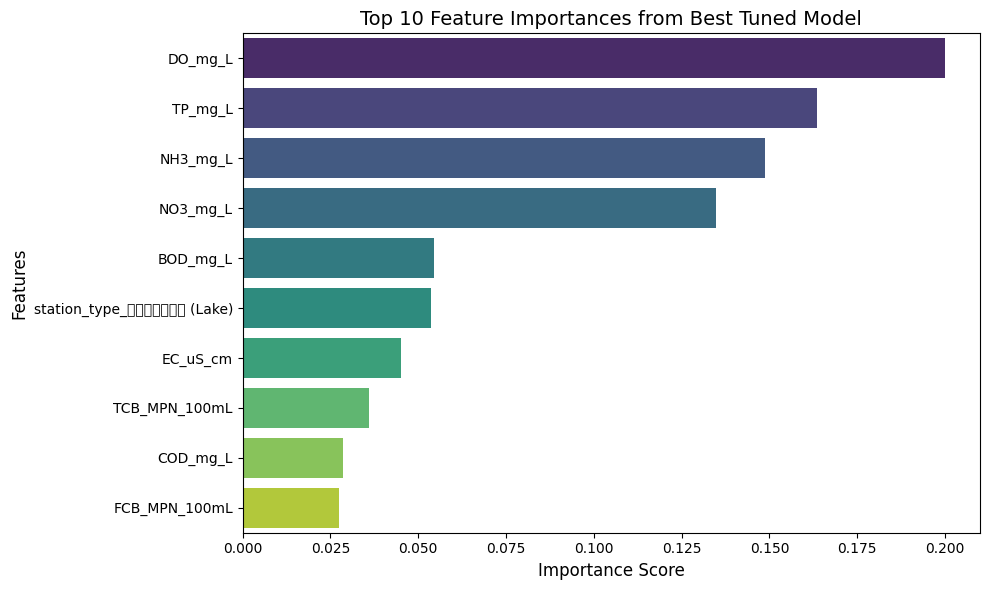


--- ตัวอย่างการพยากรณ์ความน่าจะเป็น (Prediction Probability) 5 แถวแรก ---
ตัวอย่างที่ 1 | ของจริง: B (ดี) --> ทำนายว่า: B (ดี)
   - คลาส A (ดีมาก): 0.0%
   - คลาส B (ดี): 100.0%
   - คลาส C (พอใช้): 0.0%
   - คลาส D (เสื่อมโทรม): 0.0%
----------------------------------------
ตัวอย่างที่ 2 | ของจริง: A (ดีมาก) --> ทำนายว่า: A (ดีมาก)
   - คลาส A (ดีมาก): 70.5%
   - คลาส B (ดี): 29.5%
   - คลาส C (พอใช้): 0.0%
   - คลาส D (เสื่อมโทรม): 0.0%
----------------------------------------
ตัวอย่างที่ 3 | ของจริง: A (ดีมาก) --> ทำนายว่า: A (ดีมาก)
   - คลาส A (ดีมาก): 95.9%
   - คลาส B (ดี): 4.1%
   - คลาส C (พอใช้): 0.0%
   - คลาส D (เสื่อมโทรม): 0.0%
----------------------------------------
ตัวอย่างที่ 4 | ของจริง: C (พอใช้) --> ทำนายว่า: C (พอใช้)
   - คลาส A (ดีมาก): 0.0%
   - คลาส B (ดี): 0.0%
   - คลาส C (พอใช้): 89.5%
   - คลาส D (เสื่อมโทรม): 10.5%
----------------------------------------
ตัวอย่างที่ 5 | ของจริง: A (ดีมาก) --> ทำนายว่า: A (ดีมาก)
   - คลาส A (ดีมาก): 83.5%
   - คลาส B (ด

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. โหลดข้อมูล
df = pd.read_csv("dataset1_nonghan_water_quality.csv")

# 2. เตรียม Features (X) และ Target (y)
X = df.drop(columns=['record_id', 'date', 'WQI_al_score', 'WQI_al_class'])
X = pd.get_dummies(X, columns=['season', 'station_id', 'station_type', 'tambon'], drop_first=True)
y = df['WQI_al_class']

# 3. แบ่งข้อมูล Train 80% / Test 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. ตั้งค่า Hyperparameters และสร้าง GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 5. ฝึกสอนโมเดล Random Forest
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 6. แสดงพารามิเตอร์ที่ดีที่สุดหลังจาก Fit แล้ว
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 7. ทำนายผลบน Test Set ด้วยโมเดลที่ดีที่สุด
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# แก้ไขจาก y_true เป็น y_test
cm = confusion_matrix(y_test, y_pred)

print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", cm)

# ==========================================
# 8. Visualizations & Advanced Outputs (ส่วนเสริมที่เพิ่มเข้ามา)
# ==========================================

# 8.1 Confusion Matrix Heatmap (มองเห็นภาพชัดเจนว่าโมเดลทายถูก/ผิดตรงไหน)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.tight_layout()
plt.show()

# 8.2 Feature Importance Plot (ดูว่าฟีเจอร์ไหนมีอิทธิพลต่อโมเดลที่ดีที่สุดนี้มากที่สุด)
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[top_indices], y=X.columns[top_indices], palette='viridis')
plt.title(f'Top {top_n} Feature Importances from Best Tuned Model', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 8.3 Prediction Probability (แสดงระดับความมั่นใจของโมเดลสำหรับ 5 แถวแรกในชุดทดสอบ)
y_pred_prob = best_model.predict_proba(X_test.head(5))
print("\n--- ตัวอย่างการพยากรณ์ความน่าจะเป็น (Prediction Probability) 5 แถวแรก ---")
for i in range(5):
    probs = y_pred_prob[i]
    predicted_class = best_model.classes_[np.argmax(probs)]
    actual_class = y_test.iloc[i]

    print(f"ตัวอย่างที่ {i+1} | ของจริง: {actual_class} --> ทำนายว่า: {predicted_class}")
    for cls, p in zip(best_model.classes_, probs):
        print(f"   - คลาส {cls}: {p*100:.1f}%")
    print("-" * 40)

In [ ]:
import joblib

# 1. บันทึกตัวโมเดลที่ดีที่สุด (best_model)
joblib.dump(best_model, 'water_quality_model.pkl')

# 2. บันทึกรายชื่อฟีเจอร์ (X.columns) ไว้ด้วย เพื่อใช้เช็กความถูกต้องตอนรับค่าหน้าเว็บ
joblib.dump(X.columns, 'model_features.pkl')

print("บันทึกโมเดลเรียบร้อยแล้ว!")

In [ ]:
!pip install -q streamlit


**Regressoing**



$$WQI\_Score = 59.98 + 4.44(DO) - 5.71(NH_3) - 4.99(TP) - 3.33(NO_3)$$

Data Preparation & Target Definition (การสร้างเป้าหมายการทำนาย)
เนื่องจากเป้าหมายคือการหาว่า "กี่วันถึงจะเสี่ยง (Class D)" เราต้องคำนวณระยะเวลา (Days to Class D) สำหรับทุกๆ แถวข้อมูล โดยดูข้อมูลไปข้างหน้า (Forward-looking) ของแต่ละสถานี

In [ ]:
df.max()

,0
record_id,5000
date,2025-12-30
year_be,2568
month,12
season,ฤดูแล้ง
station_id,NHK10
station_type,หนองหาร (Lake)
tambon,เหล่าปอแดง
pH,8.44
temp_c,34.7


In [ ]:
import pandas as pd
import numpy as np

# 1. โหลดข้อมูลและเรียงตามเวลา
df = pd.read_csv("dataset1_nonghan_water_quality.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['station_id', 'date'])

# 2. สร้างคอลัมน์ตรวจสอบว่าแถวนั้นเป็น Class D หรือไม่
df['is_D'] = (df['WQI_al_class'] == 'D (เสื่อมโทรม)').astype(int)

# 3. คำนวณวันที่ที่เกิด Class D ครั้งถัดไป ของแต่ละสถานี
def find_next_D(group):
    # วันที่ที่สถานะนั้นเกิด Class D
    d_dates = group.loc[group['is_D'] == 1, 'date'].values

    next_d_days = []
    for current_date in group['date']:
        # หาวันที่เกิด Class D ที่เกิดขึ้น 'หลังจาก' วันที่ปัจจุบัน
        future_d = d_dates[d_dates > current_date]
        if len(future_d) > 0:
            # คำนวณส่วนต่างจำนวนวัน
            days_diff = (future_d[0] - current_date) / np.timedelta64(1, 'D')
            next_d_days.append(days_diff)
        else:
            # ถ้าไม่มี Class D เกิดขึ้นอีกในอนาคต ให้เป็น NaN ไปก่อน
            next_d_days.append(np.nan)

    group['days_to_next_D'] = next_d_days
    return group

df = df.groupby('station_id', group_keys=False).apply(find_next_D)

# 4. สร้าง Target Variable: จะเกิด Class D ในอีก 30 วันข้างหน้าหรือไม่?
# กำหนด Time Window เช่น ทำนายล่วงหน้า 30 วัน
prediction_window = 30
df['target_D_in_30_days'] = ((df['days_to_next_D'] > 0) & (df['days_to_next_D'] <= prediction_window)).astype(int)

# ลบแถวที่เป็น Class D อยู่แล้วในวันปัจจุบันออก (เพราะเราอยากทำนายอนาคต ไม่ใช่สถานะปัจจุบัน)
df_model = df[df['is_D'] == 0].copy()

print(df_model['target_D_in_30_days'].value_counts())

target_D_in_30_days
0    4070
1     590
Name: count, dtype: int64


ขั้นตอนที่ 2: Time-Series Feature Engineering
เมื่อทำงานกับ Time-Series การให้โมเดลดูข้อมูลปัจจุบันอย่างเดียวไม่พอ ต้องให้โมเดลจำ "อดีต (Lag features)" และ "แนวโน้ม (Rolling Window)" ด้วย

In [ ]:
# 1. จัดการตัวแปร Categorical
df_model = pd.get_dummies(df_model, columns=['station_type', 'tambon', 'season'], drop_first=True)

# 2. แปลงเวลาเป็น Cyclical Feature (เดือน)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month']/12.0)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month']/12.0)

# คัดเลือกเฉพาะคอลัมน์เคมีที่สำคัญ
chem_cols = ['DO_mg_L', 'BOD_mg_L', 'NH3_mg_L', 'NO3_mg_L', 'TP_mg_L', 'TCB_MPN_100mL']

# 3. สร้าง Lag Features (ดูค่าย้อนหลัง 1 สเตปของแต่ละสถานี)
df_model = df_model.sort_values(by=['station_id', 'date'])
for col in chem_cols:
    df_model[f'{col}_lag1'] = df_model.groupby('station_id')[col].shift(1)

    # คำนวณความเปลี่ยนแปลง (Trend) ระหว่างค่าปัจจุบันกับอดีต
    df_model[f'{col}_diff'] = df_model[col] - df_model[f'{col}_lag1']

# ลบค่า Missing Values ที่เกิดจากการทำ Shift() แถวแรกของแต่ละสถานี
df_model = df_model.dropna(subset=[f'{c}_lag1' for c in chem_cols])

Train-Test Split (แบ่งข้อมูลตามเวลา)
สำคัญมาก: การทำโมเดลพยากรณ์อนาคต ห้ามสุ่มแบบ Random (train_test_split ทั่วไป) เด็ดขาด เพราะโมเดลจะแอบเห็นอนาคต (Data Leakage) เราต้องแบ่งข้อมูลแบบตัดตามเวลา (Time-based split)

In [ ]:
from sklearn.model_selection import train_test_split

# ตัดข้อมูลโดยใช้เวลาเป็นเกณฑ์ (เช่น ให้ข้อมูล 80% แรกในแกนเวลาเป็น Train, 20% หลังเป็น Test)
# หรือถ้าแบ่งตามปี เช่น Train ด้วยปี 2567, Test ด้วยปี 2568
train_df = df_model[df_model['year_be'] == 2567]
test_df = df_model[df_model['year_be'] == 2568]

# เตรียม Features (X) และ Target (y)
features = [col for col in df_model.columns if col not in [
    'record_id', 'date', 'month', 'year_be', 'station_id', 'WQI_al_class',
    'is_D', 'days_to_next_D', 'target_D_in_30_days', 'WQI_al_score'
]]

X_train = train_df[features]
y_train = train_df['target_D_in_30_days']

X_test = test_df[features]
y_test = test_df['target_D_in_30_days']

ขั้นตอนที่ 4: Modeling & Evaluation (เทรนและประเมินผล)
สำหรับการทำ Classification บนข้อมูลตาราง (Tabular) อัลกอริทึมกลุ่ม Tree-based อย่าง Random Forest หรือ XGBoost จะทำงานได้ดีและทนทานต่อ Outlier (เช่น ค่าแบคทีเรียที่สูงมาก)

In [ ]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ==========================
# 1. สร้างโมเดล
# ==========================
rf = RandomForestClassifier(
    random_state=42
)

# ==========================
# 2. กำหนด Parameter ที่ต้องการค้นหา
# ==========================
param_grid = {
    'n_estimators': [100, 200, 300],

    'max_depth': [None, 10, 20, 30],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2'],

    'bootstrap': [True, False],

    'class_weight': ['balanced']
}

# ==========================
# 3. Cross Validation
# ==========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==========================
# 4. Grid Search
# ==========================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

# ==========================
# 5. Train
# ==========================
grid_search.fit(X_train, y_train)

# ==========================
# 6. Best Parameter
# ==========================
print("="*50)
print("Best Parameters")
print("="*50)

print(grid_search.best_params_)

print("\nBest CV ROC-AUC : {:.4f}".format(grid_search.best_score_))

# ==========================
# 7. โมเดลที่ดีที่สุด
# ==========================
best_model = grid_search.best_estimator_

# ==========================
# 8. Predict
# ==========================
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

# ==========================
# 9. Evaluation
# ==========================
print("\n")
print("="*50)
print("Classification Report")
print("="*50)

print(classification_report(y_test, y_pred))

print("="*50)
print("Confusion Matrix")
print("="*50)

print(confusion_matrix(y_test, y_pred))

print("="*50)
print("ROC-AUC")
print("="*50)

print(roc_auc_score(y_test, y_prob))

# ==========================
# 10. Feature Importance
# ==========================
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("="*50)
print("Top 10 Important Features")
print("="*50)

print(feature_importance.head(10))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters
{'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV ROC-AUC : 0.9949


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2036
           1       0.76      0.94      0.84       293

    accuracy                           0.95      2329
   macro avg       0.87      0.95      0.91      2329
weighted avg       0.96      0.95      0.96      2329

Confusion Matrix
[[1947   89]
 [  17  276]]
ROC-AUC
0.9861033814546357


Top 10 Important Features
          Feature  Importance
33   TP_mg_L_lag1    0.192529
8         TP_mg_L    0.178775
6        NH3_mg_L    0.105667
29  NH3_mg_L_lag1    0.096919
7        NO3_mg_L    0.084774
31  NO3_mg_L_lag1    0.073142
27  BOD_mg_L_lag1    0.051366
25   DO_mg_L_lag1    0.042626
4        BOD_mg_

In [ ]:
import joblib

# บันทึกโมเดลที่ดีที่สุด
joblib.dump(best_model, "random_forest_model.pkl")

print("Model saved successfully")

Model saved successfully
